In [11]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import pickle
import os 

from scipy.special import lambertw
from scipy.stats import poisson 

import scipy.sparse
from matplotlib.lines import Line2D 

from multiprocessing import Pool

from tqdm import tqdm


# Plot

In [2]:
# ! cp -r ~/adipose_ln/atac/res/VIB_10xmultiome_2_OG/cluster_barcodes/ ~/adipose_ln/atac/res/VIB_10xmultiome_2_WS3000/.

In [3]:
precision=1e-7

fig_res_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_RES'

In [4]:
# ws = 2000000
# ws = 1000000
# ws = 100000
# ws = 50000  # Might be too big
# ws = 30000  # might be too big
# ws = 10000
# ws=5000
ws = 3000
# ws=500
# ws=300

output_dir = f'/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS{ws}'
chromosome = 'chr1'

crbarcode_file = os.path.join(output_dir, '/outs/filtered_peak_bc_matrix/barcodes.tsv')

frag_overlap_subdir = os.path.join(output_dir, 'fragments_overlap_peaks')

entropy_cutoff_file = os.path.join(output_dir, 'entropy_cutoff.csv')


In [5]:
tn5_inser_freq_file = os.path.join(output_dir, f'{chromosome}_insert_frequency.pickle')

with open(tn5_inser_freq_file, 'rb') as f:
    tn5_insert_freq = pickle.load(f)

In [6]:
entropy_file = os.path.join(output_dir, f'{chromosome}_barcode_entropy.pickle')

with open(entropy_file, 'rb') as f:
    entropy_dict = pickle.load(f)
    
    
entropy = np.array(list(entropy_dict.values()))
entropy.sort() # sort the entropy values


bc_entropy = pd.DataFrame.from_dict(entropy_dict, orient='index', columns=['entropy'])


with open(entropy_cutoff_file, 'r') as f:
    entropy_cutoff = float(f.readline().strip().split(',')[1])

In [7]:
summary_statistics_frag_overlap_entropypeaks_df = pd.read_csv(os.path.join(frag_overlap_subdir,
                                                                          'summary_statistics_frag_overlap_entropypeaks.csv'), sep='\t', 
                                                              index_col=0)
summary_statistics_frag_overlap_entropypeaks_df.index.name = None

summary_statistics_frag_overlap_peaks_df = pd.read_csv(os.path.join(frag_overlap_subdir,
                                                                 'summary_statistics_frag_overlap_peaks.csv'), sep='\t', 
                                                     index_col=0)
summary_statistics_frag_overlap_peaks_df.index.name = None

In [9]:

def mixdist_mle_entropy(tn5_insert_array:scipy.sparse):
    
    Mtotal = tn5_insert_array.shape[1] # total number of windows
    
    row_indices, col_indices, non0_insert =scipy.sparse.find(tn5_insert_array)
    Mnon0 = non0_insert.shape[0]
    
    
    non0_insert_adjusted = (non0_insert + 1) // 2 # adjust for paired-end sequencing
    cur_adjusted, freq_adjusted = np.unique(non0_insert_adjusted, return_counts=True)
    
    ZTP_prob = freq_adjusted / Mnon0
    mean_adjusted = np.matmul(cur_adjusted, ZTP_prob) 

    # Lambert W function requires (-M1 * exp(-M1)) > -1/e --> mean_adjusted > 1 
    mle_lambda = lambertw( -mean_adjusted * np.exp(-mean_adjusted) , k=0).real + mean_adjusted
    P0 = np.exp(-mle_lambda)
    
    N0_openregion = Mnon0 / ( 1- P0) * P0
    p_closestate = 1 -  (N0_openregion + Mnon0) / Mtotal
    
    if p_closestate < 0:
        Entropy_mixturedist, Entropy_openregion, p_closestate = None, None, None
        return Entropy_mixturedist, Entropy_openregion, Mnon0, mle_lambda, P0, p_closestate

    # Entropy of mix states
    Entropy_states = -np.log2( p_closestate ) * p_closestate - np.log2(1 - p_closestate) * (1 - p_closestate)
    
    # Entropy only for open regions under Poisson model
    Poisson_prob = ZTP_prob * (1 - P0) # Only for non-zero windows in open region
    Entropy_openregion = -np.matmul(Poisson_prob, np.log2(Poisson_prob)) - P0 * np.log2(P0) 
    
    Entropy_mixturedist = Entropy_states + (1 - p_closestate) * Entropy_openregion
    
    return Entropy_mixturedist, Entropy_openregion, Mnon0, mle_lambda, P0, p_closestate


def kl_divergence(mle_lambda, cur, freq):
    """ Compute KL divergence D_KL(P||Q) for discrete distributions
        p and q are arrays of the same length representing probability distributions
    """
    # q is from Poisson distribution with parameter mle_lambda
    
    p = freq / np.sum(freq)
    log_q = np.array([poisson.logpmf(k, mle_lambda) for k in cur]) 
    
    divergence = np.sum( p * (np.log(p) - log_q) )
    
    return divergence

In [23]:
barcode_entropy_df_file = os.path.join(output_dir, f'{chromosome}_barcode_entropy_dynamic.csv')

with open(barcode_entropy_df_file, 'w') as f:
            f.write(",Entropy_mixturedist,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state\n")
            for bc, v in tqdm(tn5_insert_freq.items(), desc="Calculating entropy for each cell barcode"):
                Entropy_mixturedist, Entropy_open_region, Mp, mle_lambda, p0, p_closed_state = mixdist_mle_entropy(v)
                if np.isnan(Entropy_mixturedist):
                    continue
                f.write(f"{bc},{Entropy_mixturedist},{Entropy_open_region},{Mp},{mle_lambda},{p0},{p_closed_state}\n")


Calculating entropy for each cell barcode: 100%|██████████| 87945/87945 [00:13<00:00, 6286.64it/s]


In [ ]:
entropy_df = summary_statistics_frag_overlap_entropypeaks_df.join(summary_statistics_frag_overlap_peaks_df,
                                                                  lsuffix='_entropypeaks', rsuffix='_peaks')

entropy_df = entropy_df.join(bc_entropy, how='outer')


entropy_dyn_df = pd.read_csv(barcode_entropy_df_file, index_col=0 )

entropy_df = entropy_df.join(entropy_dyn_df, how='inner')

In [30]:
# entropy_df['ssize_adj_entropy'] = entropy_df['entropy_mixdist_c'] - \
#     (1 - entropy_df['P_closed_state']) * (entropy_df['entropy_open_region'] - entropy_df['entropy_open_region'] / entropy_df['Mp'] * (1 - entropy_df['P0_open_region']))

entropy_df['ssize_adj_entropy'] = entropy_df['Entropy_mixturedist'] - \
    (1 - entropy_df['P_closed_state']) * (entropy_df['Entropy_open_region'] - entropy_df['Entropy_open_region'] / entropy_df['Mp'] )

In [31]:
entropy_df.head()

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy,Entropy_mixturedist,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,ssize_adj_entropy
AAACAAGCAAACCTAG-1,207,16.0,7.729469,207,16.0,7.729469,0.004289,0.012091,1.123864,25,0.376438,0.686302,0.999040,0.011055
AAACAAGCAAAGAAGC-1,987,43.0,4.356636,987,43.0,4.356636,0.012653,0.013743,2.467013,72,2.094841,0.123090,0.999011,0.011336
AAACAAGCAAATCCCT-1,242,21.0,8.677686,242,21.0,8.677686,0.003308,0.011013,0.903598,19,0.300738,0.740272,0.999118,0.010258
AAACAAGCAACAGGGA-1,107,16.0,14.953271,107,16.0,14.953271,0.002327,0.006105,1.070946,13,0.430714,0.650044,0.999552,0.005663
AAACAAGCAAGGGCTT-1,66,7.0,10.606061,66,7.0,10.606061,0.001907,0.004103,1.181182,10,0.549861,0.577030,0.999715,0.003800


## Load CR's barcodes info 

In [32]:
cr_clustering_file = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/atac/VIB_10xmultiome_2/outs/analysis/clustering/graphclust/clusters.csv'

cr_clustering_df = pd.read_csv(cr_clustering_file, sep=',', index_col=0)

In [33]:
all_df = entropy_df.join(cr_clustering_df, how='outer')
all_df['log(total_fragments)'] = np.log10(all_df['total_fragments_entropypeaks'] + precision)
all_df['log(entropy)'] = np.log10(all_df['entropy'] + precision)
# Create a binary column indicating whether a barcode is a cell by CR's cell calling
all_df['cr_bc'] = ~all_df['Cluster'].isna()

In [34]:
all_df.head()

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy,Entropy_mixturedist,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,ssize_adj_entropy,Cluster,log(total_fragments),log(entropy),cr_bc
AAACAAGCAAACCTAG-1,207.0,16.0,7.729469,207.0,16.0,7.729469,0.004289,0.012091,1.123864,25.0,0.376438,0.686302,0.999040,0.011055,NaN,2.315970,-2.367657,False
AAACAAGCAAAGAAGC-1,987.0,43.0,4.356636,987.0,43.0,4.356636,0.012653,0.013743,2.467013,72.0,2.094841,0.123090,0.999011,0.011336,NaN,2.994317,-1.897813,False
AAACAAGCAAATCCCT-1,242.0,21.0,8.677686,242.0,21.0,8.677686,0.003308,0.011013,0.903598,19.0,0.300738,0.740272,0.999118,0.010258,NaN,2.383815,-2.480416,False
AAACAAGCAACAGGGA-1,107.0,16.0,14.953271,107.0,16.0,14.953271,0.002327,0.006105,1.070946,13.0,0.430714,0.650044,0.999552,0.005663,NaN,2.029384,-2.633142,False
AAACAAGCAAGGGCTT-1,66.0,7.0,10.606061,66.0,7.0,10.606061,0.001907,0.004103,1.181182,10.0,0.549861,0.577030,0.999715,0.003800,NaN,1.819544,-2.719715,False


# Plot ratio (estimate of (1-P0)/ P0)

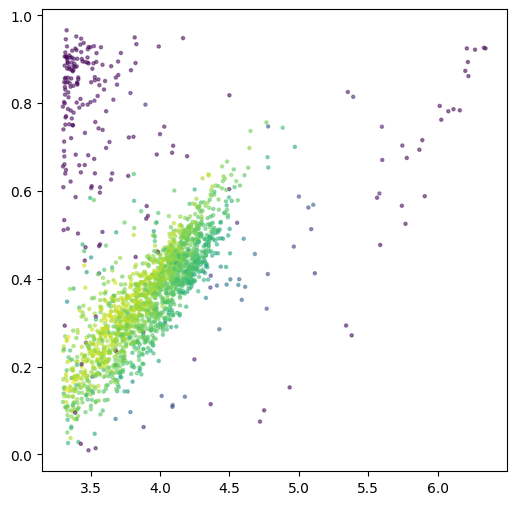

In [35]:
a_df = all_df[all_df['log(total_fragments)'] > 3.3]

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(  a_df['log(total_fragments)'],  1 - a_df['P0_open_region'] ,
           c = a_df['frag_overlap_entropy_peaks%'],
           s=5, alpha=0.5)

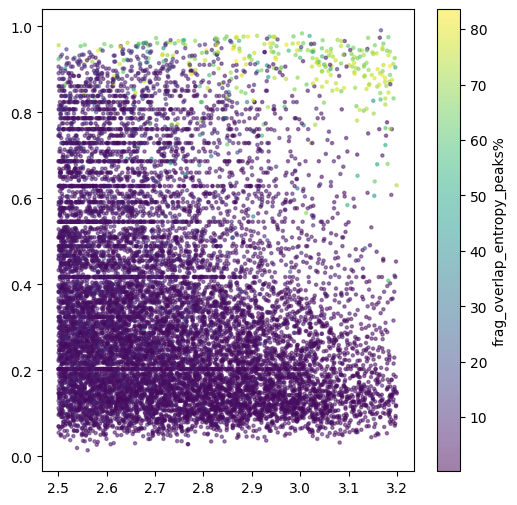

In [36]:
a_df = all_df[(all_df['log(total_fragments)'] > 2.5) & (all_df['log(total_fragments)'] < 3.2)]

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter( a_df['log(total_fragments)'], 
              a_df['P0_open_region'], c= a_df['frag_overlap_entropy_peaks%'], s=5, alpha=0.5)
fig.colorbar(ax.collections[0], ax=ax, label='frag_overlap_entropy_peaks%')

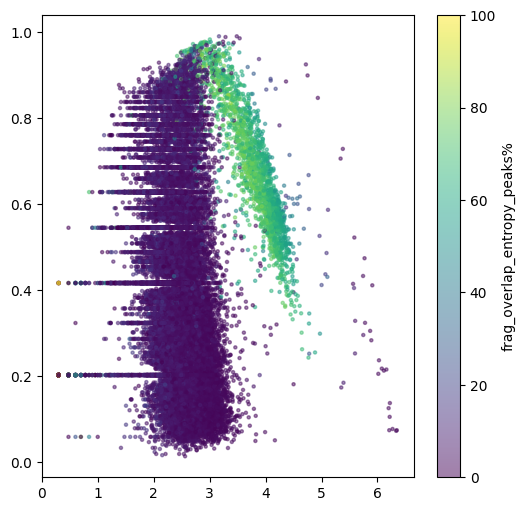

In [37]:

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter( all_df['log(total_fragments)'], 
              all_df['P0_open_region'], c= all_df['frag_overlap_entropy_peaks%'], s=5, alpha=0.5)
fig.colorbar(ax.collections[0], ax=ax, label='frag_overlap_entropy_peaks%')

## Plot Mixture Entropy

In [ ]:
## see different entropy calculation

/tmp/ipykernel_3368102/128489935.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['ssize_adj_entropy']+ precision),  c=all_df['cr_bc'].map({True: 'orange', False: 'navy'}),


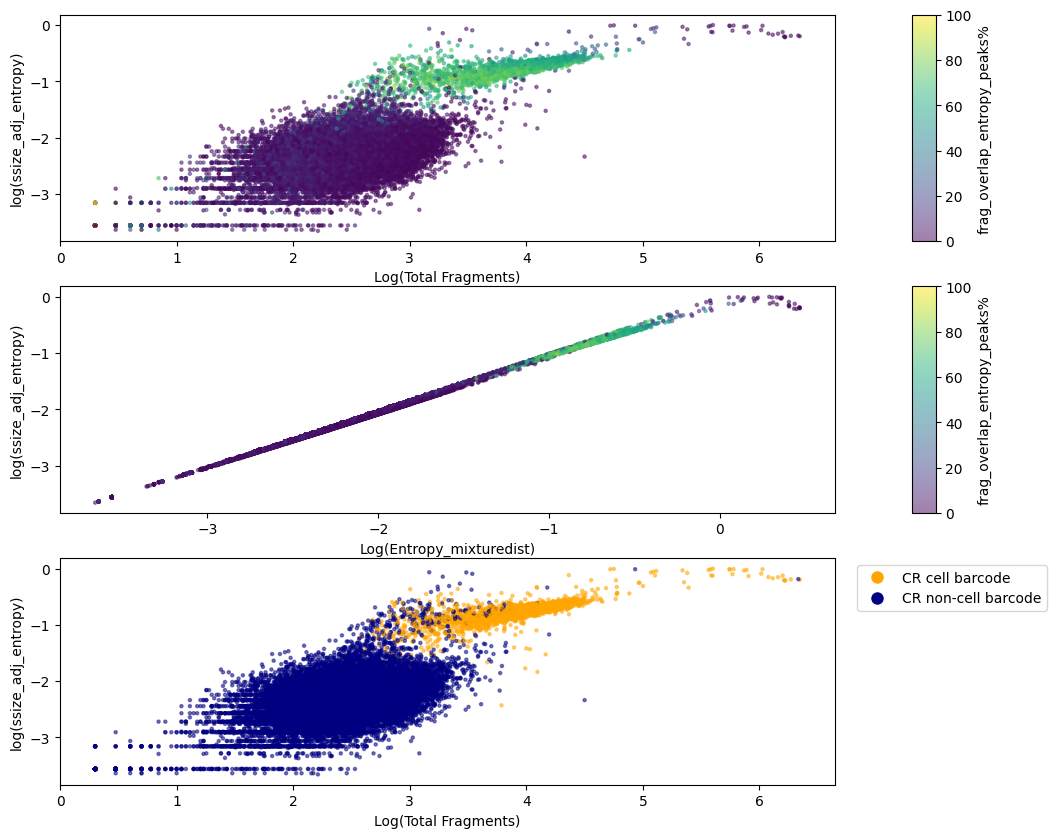

In [39]:


fig, ax = plt.subplots(3, 1, figsize=(10,10))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['ssize_adj_entropy']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(ssize_adj_entropy)')

ax[1].scatter(np.log10(all_df['Entropy_mixturedist']+ precision), np.log10(all_df['ssize_adj_entropy']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(Entropy_mixturedist)')
ax[1].set_ylabel('log(ssize_adj_entropy)')



ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['ssize_adj_entropy']+ precision),  c=all_df['cr_bc'].map({True: 'orange', False: 'navy'}),
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(ssize_adj_entropy)')
ax[2].legend( handles=[Line2D([0], [0], marker='o', color='w', label='CR cell barcode',
                          markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='CR non-cell barcode',
                           markerfacecolor='navy', markersize=10)],
           bbox_to_anchor=(1.02, 1), loc='upper left')

# Align colorbar and legend
cbax_0 = ax[0].inset_axes([1.1, 0, 0.03, 1], transform=ax[0].transAxes)
fig.colorbar(ax[0].collections[0], ax=ax[0], cax=cbax_0, label='frag_overlap_entropy_peaks%')


cbax_1 = ax[1].inset_axes([1.1, 0, 0.03, 1], transform=ax[1].transAxes)
fig.colorbar(ax[1].collections[0], ax=ax[1], cax=cbax_1, label='frag_overlap_entropy_peaks%')


fig.subplots_adjust(wspace=0.3)

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10,8))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_mixdist_c)')




ax[1].scatter(all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']+ precision),  c=all_df['cr_bc'].map({True: 'orange', False: 'navy'}),
              alpha=0.5, s=5, cmap='coolwarm')
ax[1].set_xlabel('Log(Total Fragments)')
ax[1].set_ylabel('log(entropy_mixdist_c)')
ax[1].legend( handles=[Line2D([0], [0], marker='o', color='w', label='CR cell barcode',
                          markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='CR non-cell barcode',
                           markerfacecolor='navy', markersize=10)],
           bbox_to_anchor=(1.02, 1), loc='upper left')

# Align colorbar and legend
cbax_0 = ax[0].inset_axes([1.1, 0, 0.03, 1], transform=ax[0].transAxes)
fig.colorbar(ax[0].collections[0], ax=ax[0], cax=cbax_0, label='frag_overlap_entropy_peaks%')



fig.subplots_adjust(wspace=0.3)

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10,8))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_mixdist_c)')
ax[0].axvline(np.log10(500), color='red', linestyle='--', label='seq-depth=500')
ax[0].text(np.log10(500), .5, 'seq-depth=500', color='red')




ax[1].scatter(all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']+ precision),  c=all_df['cr_bc'].map({True: 'orange', False: 'navy'}),
              alpha=0.5, s=5, cmap='coolwarm')
ax[1].set_xlabel('Log(Total Fragments)')
ax[1].set_ylabel('log(entropy_mixdist_c)')
ax[1].legend( handles=[Line2D([0], [0], marker='o', color='w', label='CR cell barcode',
                          markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='CR non-cell barcode',
                           markerfacecolor='navy', markersize=10)],
           bbox_to_anchor=(1.02, 1), loc='upper left')

# Align colorbar and legend
cbax_0 = ax[0].inset_axes([1.1, 0, 0.03, 1], transform=ax[0].transAxes)
fig.colorbar(ax[0].collections[0], ax=ax[0], cax=cbax_0, label='frag_overlap_entropy_peaks%')


fig.subplots_adjust(wspace=0.3)

# And what

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12 ,6))
ax = ax.flatten()
ax[0].violinplot([np.log10(all_df.loc[all_df['cr_bc'], 'entropy_mixdist_c'].dropna()+ precision) ,
                          np.log10(all_df.loc[~all_df['cr_bc'], 'entropy_mixdist_c'].dropna()+ precision)],
               showmeans=False)
ax[0].set_title('Entropy_mixdist_c distribution on \n CR-called cells vs non-cells')

a_df =  all_df[all_df['entropy_mixdist_c'] > 10 **(-1.2)]
ax[1].scatter(  np.log10(a_df['entropy_mixdist_c']), a_df['kl_divergence'],  c=a_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy_mixdist_c)')
ax[1].set_ylabel('kl_divergence')
ax[1].set_title('kl divergence vs entropy_mixdist_c')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')

In [ ]:
all_df['entropy_pass'] = (all_df['entropy_mixdist_c'] > 10 ** (-1.1975644015016458))


all_df['identified_by'] = all_df.apply(
    lambda row: 'both' if row['entropy_pass'] and row['cr_bc'] else 
                ('entropy_only' if row['entropy_pass'] and not row['cr_bc'] else 
                 ('cr_only' if not row['entropy_pass'] and row['cr_bc'] else 'none')), axis=1
)

all_df['identified_by'].value_counts() , print(f'number of cells passed entropy: {all_df["entropy_pass"].values.sum()}')

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(10, 12) )
colors = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
ax[1].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']),  c= all_df['identified_by'].map(colors), alpha=0.5, s=5, 
           )
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors.items()]
ax[1].legend(title='color', handles=handles, bbox_to_anchor=(0.8, 0.5), loc='upper left')
ax[1].set_xlabel('Log(Total Fragments)')
ax[1].set_ylabel('log(Entropy)')

ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)', fontsize=14)
ax[0].set_ylabel('log(Entropy)', fontsize=14)
ax[0].axhline(-1.1975644015016458, color='green', linestyle='--', label='entropy threshold', lw=2)
ax[0].text(-1.1975644015016458, .5,  '', color='green')
ax[0].legend() 


ax[1].legend(handles=[Line2D([0], [0], marker='o', color='w', label='Both',
                          markerfacecolor='green', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Entropy only',
                           markerfacecolor='blue', markersize=10), 
                 Line2D([0], [0], marker='o', color='w', label='CR only',
                           markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='None',
                           markerfacecolor='gray', markersize=10)],
             bbox_to_anchor=(1.02, 1), loc='upper left')

ax[2].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']+ precision), c=all_df['cr_bc'].map({True: 'orange', False: 'navy'}),
                alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)', fontsize=14)
ax[2].set_ylabel('log(Entropy)', fontsize=14)
ax[2].legend( handles=[Line2D([0], [0], marker='o', color='w', label='CR good cell ',
                          markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='CR non-cell',
                           markerfacecolor='navy', markersize=10)],
           bbox_to_anchor=(1.02, 1), loc='upper left')

cax_0 = ax[0].inset_axes([1.1, 0, 0.03, 1], transform=ax[0].transAxes)
#cax_2 = ax[2].inset_axes([1.1, 0, 0.03, 1], transform=ax[2].transAxes)

fig.colorbar(ax[0].collections[0], ax=ax[0], cax=cax_0, label='Fragments% overlapping called peaks')

In [ ]:
### For figures 
import sys
current_dir = os.getcwd()
split_dir = os.path.dirname(current_dir)
sys.path.append(split_dir)
from autothreshold_kevintopush import fit_spline_and_find_cutoff

sorted_log10entropy_list = np.log10(all_df['entropy_mixdist_c'].dropna().sort_values(ascending=False).values)[:30000] # take top 30k for spline fitting
rank_list = np.arange( len(sorted_log10entropy_list) )

rank_cutoff, log10_entry_cutoff, cs = fit_spline_and_find_cutoff(rank_list, sorted_log10entropy_list, k=2, spline_s=3, spline_k=3)
print(f'rank_cutoff: {rank_cutoff}')



fig, ax = plt.subplots(3, 1, figsize=(10, 12) )
colors = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
ax[1].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']),  c= all_df['identified_by'].map(colors), alpha=0.5, s=5, 
           )
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors.items()]
ax[1].legend(title='color', handles=handles, bbox_to_anchor=(0.8, 0.5), loc='upper left')
ax[1].set_xlabel('Log(Total Fragments)', fontsize=14)
ax[1].set_ylabel('log(Entropy)', fontsize=14)

ax[0].plot( rank_list, sorted_log10entropy_list, 'o')
ax[0].plot(rank_list, cs(rank_list), color='pink', lw=2, label='spline fit')
ax[0].set_xlabel('Barcode rank', fontsize=14)
ax[0].set_ylabel('log(Entropy)', fontsize=14)
ax[0].axhline(log10_entry_cutoff, color='pink', linestyle='--', label='entropy threshold', lw=2)



ax[1].legend(handles=[Line2D([0], [0], marker='o', color='w', label='Both',
                          markerfacecolor='green', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Entropy only',
                           markerfacecolor='blue', markersize=10), 
                 Line2D([0], [0], marker='o', color='w', label='CR only',
                           markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='None',
                           markerfacecolor='gray', markersize=10)],
             bbox_to_anchor=(1.02, 1), loc='upper left')

ax[2].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']+ precision), c=all_df['cr_bc'].map({True: 'orange', False: 'navy'}),
                alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)', fontsize=14)
ax[2].set_ylabel('log(Entropy)', fontsize=14)
ax[2].legend( handles=[Line2D([0], [0], marker='o', color='w', label='CR good cell ',
                          markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='CR non-cell',
                           markerfacecolor='navy', markersize=10)],
           bbox_to_anchor=(1.02, 1), loc='upper left')

cax_0 = ax[0].inset_axes([1.1, 0, 0.03, 1], transform=ax[0].transAxes)
#cax_2 = ax[2].inset_axes([1.1, 0, 0.03, 1], transform=ax[2].transAxes)

#fig.colorbar(ax[0].collections[0], ax=ax[0], cax=cax_0, label='Fragments% overlapping called peaks')




In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
color_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}

all_df.boxplot(column=['frag_overlap_entropy_peaks%'], by='identified_by', ax=ax)
ax.set_ylim(0, 120)
ax.set_ylabel('Fragments% overlapping called peaks', fontsize=14)
ax.set_xlabel(' ')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['Both', 'CR only', 'Entropy only', 'None'], fontsize=14)
ax.set_title('Barcode quality by different cell identification methods')
for i, method in enumerate(['both', 'cr_only', 'entropy_only', 'none']):
    ax.text(i + 0.5, 110, f'{(all_df["identified_by"]==method).sum()} BCs', fontsize=14, c=color_map[method])
plt.suptitle('')

# fig, ax = plt.subplots(figsize=(8,8))
# ax.violinplot(
#     [all_df.loc[all_df['identified_by'] == 'cr_only', 'frag_overlap_entropy_peaks%'], 
#      all_df.loc[all_df['identified_by'] == 'entropy_only', 'frag_overlap_entropy_peaks%'],
#      all_df.loc[all_df['identified_by'] == 'both', 'frag_overlap_entropy_peaks%']],
#     positions=[1, 2, 3],
#      showmedians=True
# )
# ax.set_xlabel('Identified good cells')
# ax.set_ylabel('Fragments% overlapping called peaks')
# ax.set_xticks([1, 2, 3])
# ax.set_xticklabels(['CR_only', 'Entropy_only', 'Both'])

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18 ,6))
ax = ax.flatten()
ax[0].violinplot([np.log10(all_df.loc[all_df['cr_bc'], 'entropy_mixdist_c'].dropna()+ precision) ,
                          np.log10(all_df.loc[~all_df['cr_bc'], 'entropy_mixdist_c'].dropna()+ precision)],
               showmeans=False)
ax[0].set_title('Entropy_mixdist_c distribution on \n CR-called cells vs non-cells')

a_df =  all_df[all_df['entropy_mixdist_c'] > 10 **(-1.2)]
ax[1].scatter(  np.log10(a_df['entropy_mixdist_c']), a_df['kl_divergence'],  c=a_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy_mixdist_c)')
ax[1].set_ylabel('kl_divergence')
ax[1].set_title('kl_divergence can filter \n over-tagmented barcodes')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')

ax[2].scatter(  np.log10(all_df['entropy_mixdist_c']), all_df['kl_divergence'],  c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[2].set_xlabel('Log(entropy_mixdist_c)')
ax[2].set_ylabel('kl_divergence')
ax[2].set_title('kl_divergence can filter \n over-tagmented barcodes')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='frag_overlap_entropy_peaks%')

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(12,13))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_mixdist_c)')
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')

ax[1].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']),  c=all_df['entropy_pass'], 
           alpha=0.5, s=5, cmap='coolwarm')
ax[1].set_xlabel('Log(entropy)')
ax[1].set_ylabel('log(entropy_mixdist_c)')
ax[1].set_title('entropy_method')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='entropy_pass: kl<3 & entropy>10^-1.2')


ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']+ precision),  c=all_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(entropy_mixdist_c)')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')

fig.tight_layout()

## Top 20k as pre-filter 

In [ ]:
top20k_df = all_df.sort_values(by='total_fragments_entropypeaks', ascending=False).head(20000)

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
_ = ax.hist(np.log10(top20k_df['entropy_mixdist_c']), bins=100)

In [ ]:
all_df['cr_bc'].value_counts()

In [ ]:
all_df[all_df['entropy_mixdist_c'] > 10**(-1.0790962612777066)].shape

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(np.arange(20000), np.log10(top20k_df['entropy_mixdist_c'].sort_values(ascending=False) + precision), s=10)
ax.set_ylabel('log(entropy_mixdist_c)')
ax.set_xlabel('Ranked Barcodes (by entropy_mixdist_c)')

In [ ]:


special_bc = 'GACAGGCTCGAGGAGG-1'  # bad-quality cell -- probably over-tagmented 

fig, ax = plt.subplots( figsize=(12,12))
ax.scatter( top20k_df['log(total_fragments)'], np.log10(top20k_df['entropy_mixdist_c']), c=top20k_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax.set_xlabel('Log(Total Fragments)')
ax.set_ylabel('log(entropy_mixdist)')
ax.scatter(top20k_df.loc[special_bc, 'log(total_fragments)'], np.log10(top20k_df.loc[special_bc, 'entropy_mixdist_c'] + precision),
              color='red', s=50, label='special_bc')
ax.legend()


fig.colorbar(ax.collections[0], ax=ax, label='frag_overlap_entropy_peaks%')


# Non-0 window 

In [ ]:
cell_df = all_df[ (all_df['entropy_mixdist_c'] > 10 ** (-1.2)) & (all_df['total_fragments_entropypeaks'] < 10000)].copy()

special_bc = list(tn5_insert_freq.keys())[0]
total_windows = tn5_insert_freq[special_bc].shape[1] 

cell_df['N_open_regions'] = total_windows * (1 - cell_df['P_closed_state'])

for bc in cell_df.index:
    cell_df.loc[bc, 'N_nnz'] = tn5_insert_freq[bc].nnz

In [ ]:
tn5_insert_freq[special_bc].nnz

In [ ]:
cell_df.head()

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12,6))
ax[0].scatter( cell_df['total_fragments_entropypeaks'], cell_df['N_open_regions'], c=cell_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('total_fragments_entropypeaks')       
ax[0].set_ylabel('N_open_regions')
ax[0].set_ylim(0, 10000)
ax[0].set_xlim(1000, 20000)


ax[1].scatter( cell_df['total_fragments_entropypeaks'], cell_df['N_nnz'], c=cell_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('total_fragments_entropypeaks')       
ax[1].set_ylabel('N_nnz')
ax[1].set_ylim(0, 1000)
ax[1].set_xlim(0, 20000)

ax[2].scatter( cell_df['total_fragments_entropypeaks'], cell_df['mle_lambda'], c=cell_df['frag_overlap_entropy_peaks%'], 
              alpha=0.5, s=5, cmap='viridis')
ax[2].set_xlabel('total_fragments_entropypeaks')       
ax[2].set_ylabel('N_nnz')
ax[2].set_ylim(0, 2)
ax[2].set_xlim(0, 20000)

In [ ]:
cell_df['total_fragments_entropypeaks'].min()

## linear regression on read-depth v.s. non-zero winds N-nnz 

In [ ]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(  cell_df['total_fragments_entropypeaks'].values.reshape(-1, 1), cell_df['N_nnz'].values.reshape(-1, 1),)

reg.coef_, reg.intercept_

x_s = np.array([0, 10000]).reshape(-1, 1)
y_s = reg.predict(x_s)
pts = np.concatenate([x_s, y_s], axis=1)

fig, ax = plt.subplots( figsize=(6,6))
ax.scatter( cell_df['total_fragments_entropypeaks'], cell_df['N_nnz'], c=cell_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax.set_xlabel('total_fragments_entropypeaks')       
ax.set_ylabel('N_nnz')
# ax.set_ylim(0, 1000)
# ax.set_xlim(0, 20000)
ax.axline(pts[0], pts[1], color='red', linestyle='--', label='Linear Regression')

reg.coef_, reg.intercept_


In [ ]:
(54  - reg.intercept_[0]) / reg.coef_[0][0]

In [ ]:
32 / 0.0807

In [ ]:
depth = 262
np.log10(depth),  depth * reg.coef_[0][0] + reg.intercept_[0]

# See Tn5 Insertions

## Set 1

In [ ]:
subset_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-.8)) & (all_df['kl_divergence'] < 3)]

good_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-1.)) & (all_df['kl_divergence'] > 3)]

crazy_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-0.5)) & (all_df['log(total_fragments)'] > 4)]

fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = subset_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 66, 70# 82 , 82 seed is vip 

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[sample_bc[0], 'kl_divergence']

        val, freq = np.unique(tn5_insert_freq[sample_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])     
        ax[0, 0].plot(val, freq, marker='o', 
                label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)}  kl {kl_divergence_val}', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[good_bc[0], 'kl_divergence']

        val, freq = np.unique(tn5_insert_freq[good_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        ax[1, 0].plot(val[1:], freq[1:], marker='o',
                label=f'seqdepth:{bc_seq_depth}, frag-overlap:{np.round(bc_frag_overlap, 3)} kl {kl_divergence_val}', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()} ',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[crz_bc[0], 'kl_divergence']
        val, freq = np.unique(tn5_insert_freq[crz_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        ax[2, 0].plot(val[1:], freq[1   :], marker='o', label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)}  kl {kl_divergence_val}', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()

fig.suptitle('Observed tn5 insertion rates (randomly sampled barcodes)', fontsize=20)
fig.tight_layout()

In [ ]:
bc = 'AATCATGAGTATCGCC-1'

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
bc_seq_depth = int(all_df.loc[bc, 'total_fragments_entropypeaks'])
bc_logentropy_val = all_df.loc[bc, 'log(entropy)']
bc_frag_overlap = all_df.loc[bc, 'frag_overlap_entropy_peaks%']
entropy_mix = all_df.loc[bc, 'entropy_mixdist_c']
kl_divergence_val = all_df.loc[bc, 'kl_divergence']

val, freq = np.unique(tn5_insert_freq[bc].toarray(), return_counts=True)
p_non0 = freq[1:]/  np.sum(freq[1:])     
ax[0].plot(val, freq, marker='o', 
        label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)}  kl {kl_divergence_val}', alpha=0.7)
ax[ 0].tick_params(labelbottom=True)

ax[ 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
        alpha=0.7)
ax[0].legend()
ax[1].legend()

all_df.loc['AATCATGAGTATCGCC-1']


In [ ]:
possible_overtag_bc_frag = pd.read_csv('/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000/_possible_overtag_bc_frag.tsv', sep='\t', header=None)
fig, ax = plt.subplots(1, 2, figsize=(12,6))

possible_good_bc_frag = pd.read_csv('/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000/_possible_goodbc_frag.tsv', sep='\t', header=None)

ax[0].hist(possible_overtag_bc_frag[2] - possible_overtag_bc_frag[1], log=False, bins=100, label='overtag?')

ax[1].hist(possible_good_bc_frag[2] - possible_good_bc_frag[1], log=False, bins=100, label='good bc?')

ax[0].legend()
ax[1].legend()

In [ ]:
subset_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-1.2)) & (all_df['kl_divergence'] < 3)]

good_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-1.2)) & (all_df['kl_divergence'] > 3)]

crazy_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-0.5)) & (all_df['log(total_fragments)'] > 4)]

fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = subset_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 75, 78

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[sample_bc[0], 'kl_divergence']

        val, freq = break_down_freq(tn5_insert_freq[sample_bc[0]].toarray())
        freq[freq == None] =  -1 
        p_non0 = freq/  np.sum(freq)     

        ax[0, 0].plot(val, freq, marker='o', 
                label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)}  kl {kl_divergence_val}', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[2:].sum()}',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[good_bc[0], 'kl_divergence']

        val, freq = break_down_freq(tn5_insert_freq[good_bc[0]].toarray())
        freq[freq == None] =  -1 
        p_non0 = freq/  np.sum(freq) 
        ax[1, 0].plot(val, freq, marker='o',
                label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)}  kl {kl_divergence_val}', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[2:].sum()}',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[crz_bc[0], 'kl_divergence']
        
        val, freq = break_down_freq(tn5_insert_freq[crz_bc[0]].toarray())
        freq[freq == None] =  -1 
        p_non0 = freq/  np.sum(freq) 
        ax[2, 0].plot(val, freq, marker='o', label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)}  kl {kl_divergence_val}', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[2:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()
        
fig.suptitle('  ------------------    ------         ----------------------------      break down 0-freq to closed and open regions', fontsize=20)
fig.tight_layout()

In [ ]:
all_df.loc['CTCAGCTAGCCAGTAG-1']

In [ ]:
np.unique(tn5_insert_freq[crz_bc[0]].toarray(), return_counts=True)[1].sum()

In [ ]:
all_df.loc[((all_df['kl_divergence'] > 4) & (all_df['log(total_fragments)'] > 3))]

## Set 2

In [ ]:
bad_df = all_df[(all_df['entropy_final'] > 10 ** (-1.6)) & (all_df['log(total_fragments)'] < 3) & (all_df['frag_overlap_entropy_peaks%'] < 30) ]

good_df = all_df[(all_df['entropy_final'] > 10 ** (-1.6)) & (all_df['log(total_fragments)'] < 3) & (all_df['frag_overlap_entropy_peaks%'] > 50) ]

crazy_df = all_df[(all_df['log(total_fragments)'] >  3) &  (all_df['frag_overlap_entropy_peaks%'] < 30) ]


fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = bad_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 75, 78

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_final']

        val, freq = np.unique(tn5_insert_freq[sample_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])     
        ax[0, 0].plot(val[1:], freq[1:], marker='o', 
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_final']

        val, freq = np.unique(tn5_insert_freq[good_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        ax[1, 0].plot(val[1:], freq[1:], marker='o',
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_final']
        val, freq = np.unique(tn5_insert_freq[crz_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        ax[2, 0].plot(val[1:], freq[1   :], marker='o', label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()

In [ ]:
bad_df = all_df[(all_df['entropy_final'] > 10 ** (-1.6)) & (all_df['log(total_fragments)'] < 3) & (all_df['frag_overlap_entropy_peaks%'] < 30) ]

good_df = all_df[(all_df['entropy_final'] > 10 ** (-1.6)) & (all_df['log(total_fragments)'] < 3) & (all_df['frag_overlap_entropy_peaks%'] > 50) ]

crazy_df = all_df[(all_df['log(total_fragments)'] >  3) &  (all_df['frag_overlap_entropy_peaks%'] < 30) ]


fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = subset_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 75, 78

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_final']

        val, freq = break_down_freq(tn5_insert_freq[sample_bc[0]].toarray())
        p_non0 = freq/  np.sum(freq)     
        ax[0, 0].plot(val, freq, marker='o', 
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_final']

        val, freq = break_down_freq(tn5_insert_freq[good_bc[0]].toarray())
        p_non0 = freq/  np.sum(freq) 
        ax[1, 0].plot(val, freq, marker='o',
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_final']
        val, freq = break_down_freq(tn5_insert_freq[crz_bc[0]].toarray())

        val = val[freq != None]
        freq = freq[freq != None]
        p_non0 = freq/  np.sum(freq) 
        ax[2, 0].plot(val, freq, marker='o', label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()

# Plot entropy of mixture distribution

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(12,12))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_mixdist)')
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')

ax[1].scatter(all_df['log(entropy)'], np.log10(all_df['entropy_mixdist']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy)')
ax[1].set_ylabel('log(entropy_mixdist)')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')


ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist']+ precision),  c=all_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(entropy_mixdist)')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')